# DEG analysis as a pseudobulk DE workflow using edgeR’s quasi-likelihood (QL) GLM pipeline

**Purpose**

This notebook performs pseudobulk differential expression (DE) analysis to identify genes that are differentially expressed between wild-type (WT) and mutant conditions. The analysis aims to quantify transcriptional differences at the sample level by aggregating single-cell RNA-seq data and applying bulk RNA-seq statistical modeling.

**Input**

The integrated posterior midgut object obtained from notebook 6. This is used to construct a pseudobulk expression matrix where counts are aggregated across cells within each biological sample.

Sample-level metadata including: experimental condition (dataset, e.g. WT, LanB2, tinman), library identifier (library), replicate and batch information.

The pseudobulk object is imported from Python and represented in R as a SummarizedExperiment.

**Workflow overview**
edgeR preprocessing:
A DGEList object is created using the raw pseudobulk counts. Lowly expressed genes are filtered using filterByExpr, and library size normalization is performed using the TMM method (calcNormFactors).

Design matrix specification:
A linear model design matrix is constructed including biological condition (group), and technical library effect (library), allowing correction for library-specific variation.

Dispersion estimation:
Gene-wise and common dispersions are estimated using edgeR’s negative binomial framework.

Quasi-likelihood model fitting:
A quasi-likelihood generalized linear model is fitted using glmQLFit.

Differential expression testing:
Specific contrasts between conditions are tested using glmQLFTest.

Result extraction:
Differentially expressed genes are extracted using topTags.


**Output**
Tables of significantly downregulated and upregulated genes for each contrast with FDR (false discovery rate) < 0.05


**Implementation note**
The functions defined in this section follow current best practices for single-cell RNA-seq analysis, as described in the single-cell analysis guidelines and benchmarking literature (Luecken & Theis, 2019).

In [ ]:
import os
import random

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

from scipy.sparse import csr_matrix, issparse

from scipy import io

sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (4, 4)

from scipy.sparse import csr_matrix, issparse

In [ ]:
from IPython.display import display, HTML


In [ ]:
SEED = 0

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

#pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
import gseapy

In [ ]:
%%R
library(edgeR)
library(SummarizedExperiment)
library(limma)

In [ ]:
adata = sc.read('../data/processed/PMG_wt_mutants_bootstr_rep.h5ad')
adata

In [ ]:
adata = adata.raw.to_adata()
adata

In [ ]:
sc.pl.umap(adata, color='midgut_celltype')

In [ ]:
adata.X

In [ ]:
adata.obs['batch'].value_counts()

In [ ]:
adata_sub = adata[~adata.obs['batch'].isin(['WT_01'])]
adata_sub

In [ ]:
adata_sub.obs['replicate'] = adata_sub.obs['batch'].replace({'LanB_01':'replicate1', 'LanB_02':'replicate2', 'WT_02':'replicate1', 'WT_03':'replicate2',
                                                     'WT_04':'replicate3', 'tin_01':'replicate1', 'tin_02':'replicate2'})
adata_sub.obs['replicate']

In [ ]:
adata_sub.obs['batch'].value_counts()

In [ ]:
adata_sub.obs['batch'] = adata_sub.obs['batch'].astype('category')
adata_sub.obs['dataset'] = adata_sub.obs['dataset'].astype('category')
adata_sub.obs['replicate'] = adata_sub.obs['replicate'].astype('category')

The following two functions are implemented from single-cell best practice section 'Differential gene expression alaysis'

In [ ]:
NUM_OF_CELL_PER_DONOR = 80

import random
def aggregate_and_filter(
    adata,
    cell_identity,
    donor_key="batch",
    condition_key="dataset",
    cell_identity_key="midgut_celltype",
    obs_to_keep=[],  # which additional metadata to keep, e.g. gender, age, etc.
    replicates_per_patient=1,
):
    # subset adata to the given cell identity
    adata_cell_pop = adata[adata.obs[cell_identity_key] == cell_identity].copy()
    # check which donors to keep according to the number of cells specified with NUM_OF_CELL_PER_DONOR
    size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()
    donors_to_drop = [
        donor
        for donor in size_by_donor.index
        if size_by_donor[donor] <= NUM_OF_CELL_PER_DONOR
    ]
    if len(donors_to_drop) > 0:
        print("Dropping the following samples:")
        print(donors_to_drop)
    df = pd.DataFrame(columns=[*adata_cell_pop.var_names, *obs_to_keep])

    adata_cell_pop.obs[donor_key] = adata_cell_pop.obs[donor_key].astype("category")
    for i, donor in enumerate(donors := adata_cell_pop.obs[donor_key].cat.categories):
        print(f"\tProcessing donor {i+1} out of {len(donors)}...", end="\r")
        if donor not in donors_to_drop:
            adata_donor = adata_cell_pop[adata_cell_pop.obs[donor_key] == donor]
            # create replicates for each donor
            indices = list(adata_donor.obs_names)
            random.shuffle(indices)
            indices = np.array_split(np.array(indices), replicates_per_patient)
            for i, rep_idx in enumerate(indices):
                adata_replicate = adata_donor[rep_idx]
                # specify how to aggregate: sum gene expression for each gene for each donor and also keep the condition information
                agg_dict = {gene: "sum" for gene in adata_replicate.var_names}
                for obs in obs_to_keep:
                    agg_dict[obs] = "first"
                # create a df with all genes, donor and condition info
                df_donor = pd.DataFrame(adata_replicate.X)
                df_donor.index = adata_replicate.obs_names
                df_donor.columns = adata_replicate.var_names
                df_donor = df_donor.join(adata_replicate.obs[obs_to_keep])
                # aggregate
                df_donor = df_donor.groupby(donor_key).agg(agg_dict)
                df_donor[donor_key] = donor
                df.loc[f"donor_{donor}_{i}"] = df_donor.loc[donor]
    print("\n")
    # create AnnData object from the df
    adata_cell_pop = sc.AnnData(
        df[adata_cell_pop.var_names], obs=df.drop(columns=adata_cell_pop.var_names)
    )
    return adata_cell_pop

In [ ]:
%%R
fit_model <- function(adata_){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$dataset)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    print("")
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    print("")
    # normalize
    y <- calcNormFactors(y)
    
    group <- colData(adata_)$dataset
    replicate <- colData(adata_)$replicate
    library <- colData(adata_)$library
    # create a design matrix: here we have two very different library sizes so also consider that in the design matrix
    design <- model.matrix(~ group + library)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [ ]:
obs_to_keep = ["dataset", "midgut_celltype", "replicate", "batch"]

In [ ]:
adata_sub.X

In [ ]:
adata_sub

Constructing a pseudobulk count matrix per celltype(pmg) per sample and finding the source of variation using PCA plot

In [ ]:
# process first cell type separately...
cell_type = adata_sub.obs["midgut_celltype"].cat.categories[0]
print(
    f'Processing {cell_type} (1 out of {len(adata_sub.obs["midgut_celltype"].cat.categories)})...'
)
adata_pb = aggregate_and_filter(adata_sub, cell_type, obs_to_keep=obs_to_keep)
for i, cell_type in enumerate(adata_sub.obs["midgut_celltype"].cat.categories[1:]):
    print(
        f'Processing {cell_type} ({i+2} out of {len(adata_sub.obs["midgut_celltype"].cat.categories)})...'
    )
    adata_cell_type = aggregate_and_filter(adata_sub, cell_type, obs_to_keep=obs_to_keep)
    adata_pb = adata_pb.concatenate(adata_cell_type)

In [ ]:
adata_pb

In [ ]:
adata_pb.layers['counts'] = adata_pb.X.copy()

In [ ]:
adata_pb

In [ ]:
sc.pp.normalize_total(adata_pb)
sc.pp.log1p(adata_pb)
sc.pp.pca(adata_pb)

In [ ]:
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1)

In [ ]:
adata_pb.obs['lib_size']

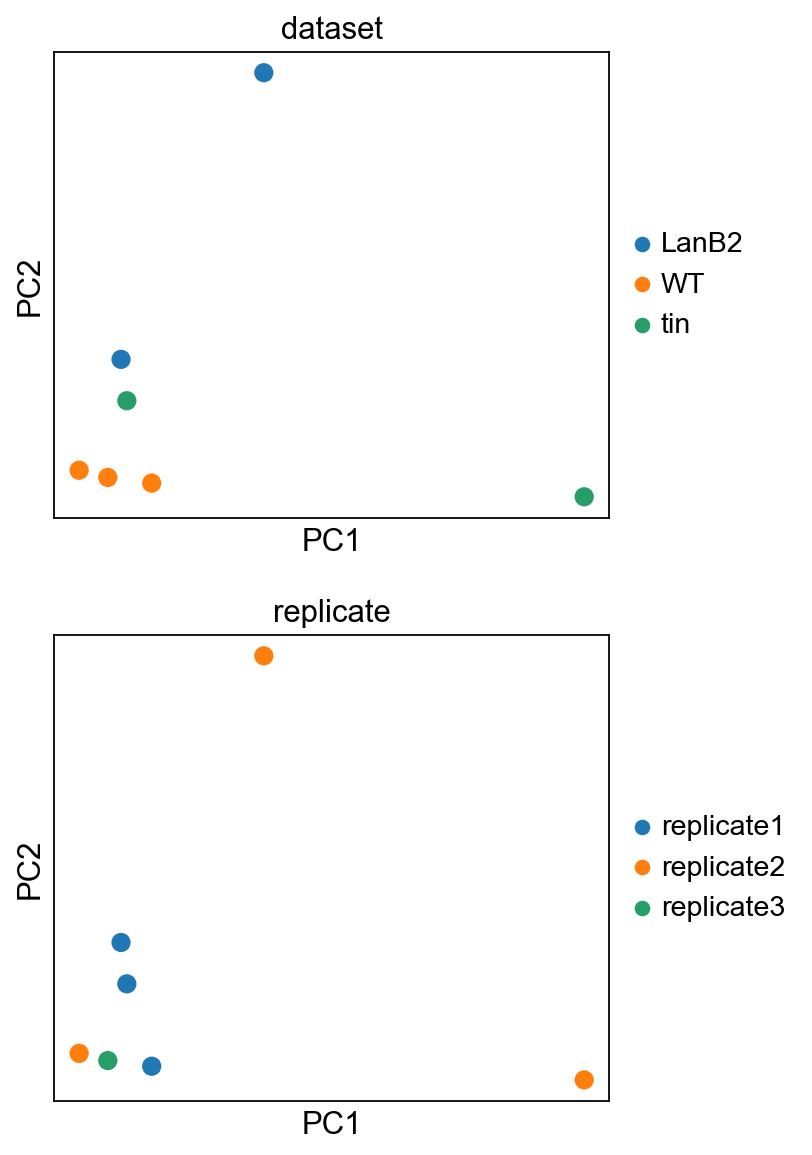

In [28]:
sc.pl.pca(adata_pb, color=['dataset', 'replicate'], ncols=1, size=300)

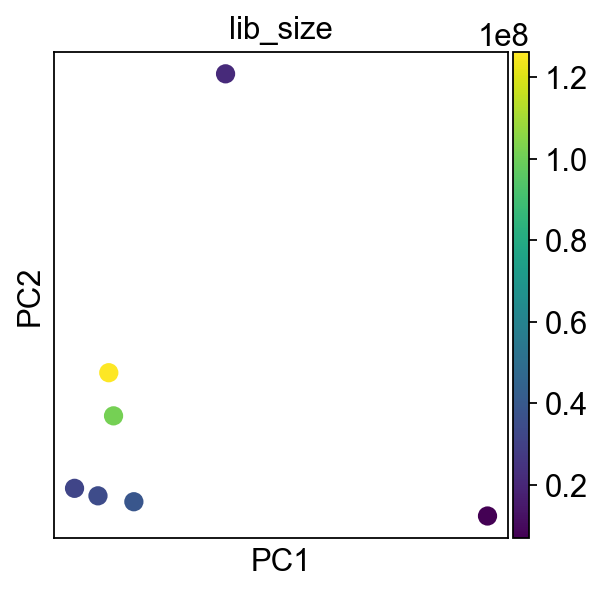

In [29]:
sc.pl.pca(adata_pb, color='lib_size', ncols=1, size=300)

#### Removing the effect of library size in PCA

In [ ]:
print(adata_pb.obs['lib_size'].dtype)

In [ ]:
adata_pb.obs['lib_size'] = pd.to_numeric(adata_pb.obs['lib_size'], errors='coerce')

In [ ]:
print(adata_pb.obs['lib_size'].dtype)

In [ ]:
print(adata_pb.obs['lib_size'].isna().sum())

In [ ]:
print(adata_pb.X.dtype)

In [ ]:
print(adata_pb.obs['batch'].dtype)

In [ ]:
adata_pb.obs['batch'] = adata_pb.obs['batch'].astype('category')

In [ ]:
print(adata_pb.obs['batch'].dtype)

In [ ]:
#Regress out library size
sc.pp.regress_out(adata_pb, keys=['lib_size'])

# Scale the data after regressing out
sc.pp.scale(adata_pb)

In [ ]:
sc.tl.pca(adata_pb)

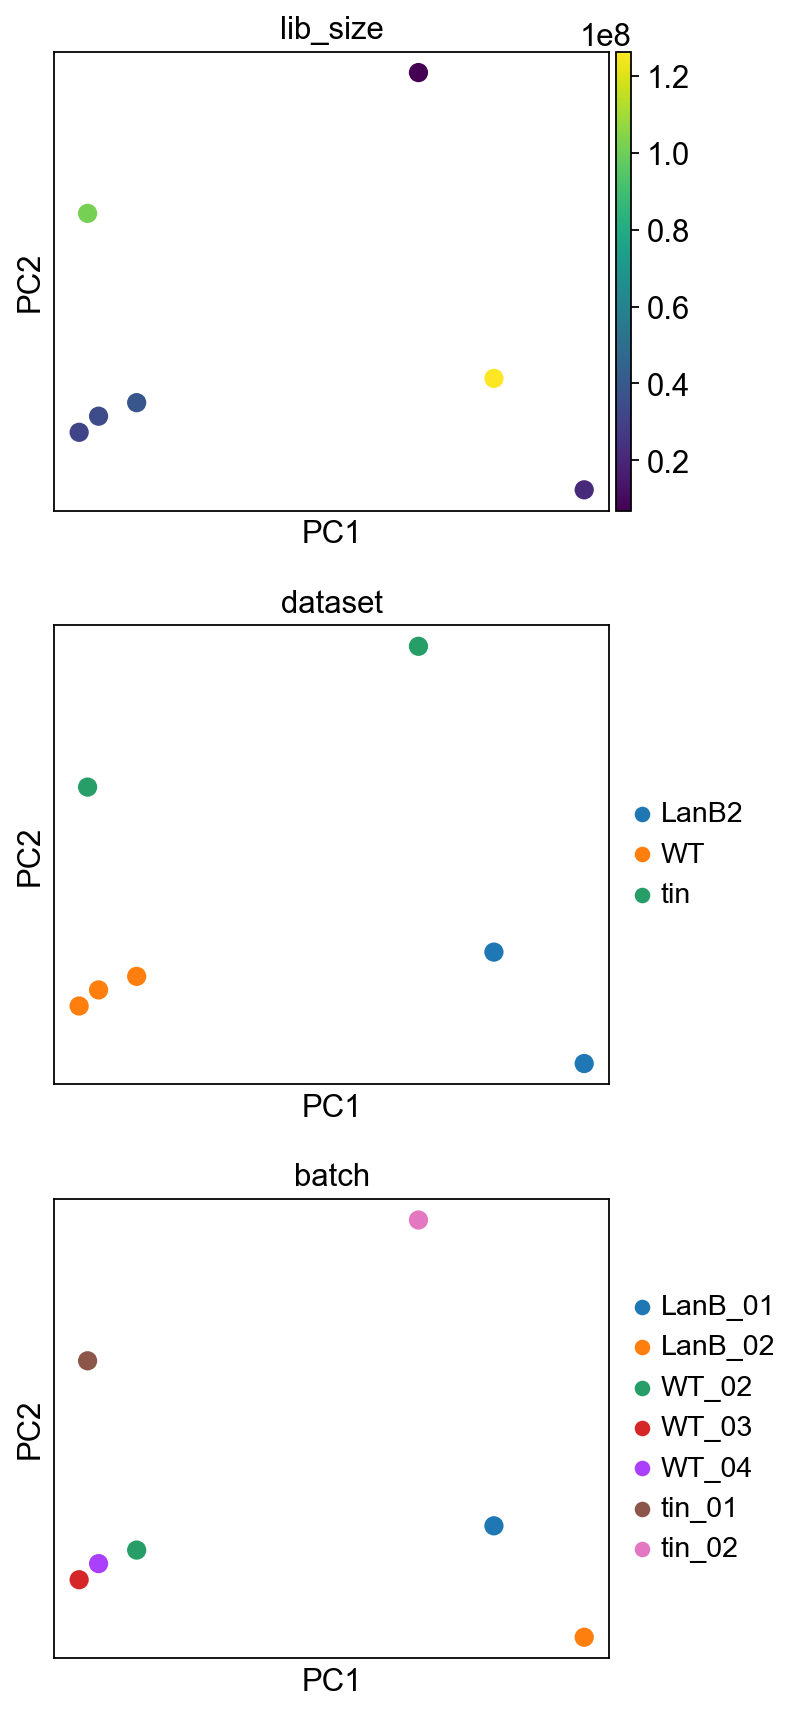

In [40]:
sc.pl.pca(adata_pb, color=['lib_size', 'dataset', 'batch'], ncols=1, size=300)

#### Removing the effect of batch in PCA (nested factor)

In [ ]:
adata_pb.X

In [ ]:
adata_pb.X = adata_pb.layers['counts'].copy()
adata_pb.X

In [ ]:
sc.pp.normalize_total(adata_pb)
sc.pp.log1p(adata_pb)

In [ ]:
#Regress out library size
sc.pp.regress_out(adata_pb, keys=['batch'])

# Scale the data after regressing out
sc.pp.scale(adata_pb)

In [ ]:
sc.tl.pca(adata_pb)

In [ ]:
sc.pl.pca(adata_pb, color=['lib_size', 'dataset', 'batch'], ncols=1, size=300)

It seems that library size (the low size for the second chips of Lan and tin) is a source of variation. It should be inlcuded in the design  matrix

Design matrix and DE analysis

In [ ]:
adata_pb.obs['batch'].unique()

In [ ]:
adata_pb.obs['library'] = adata_pb.obs['batch'].replace({'LanB_01':'library1', 'LanB_02':'library2', 'tin_01':'library1', 'tin_02':'library2', 'WT_03':'library1', 'WT_04':'library1'})

In [ ]:
adata_pb.X = adata_pb.layers['counts'].copy()

In [ ]:
adata_pb.obs_names = [
    name.split("_")[2] + "_" + name.split("_")[3] for name in adata_pb.obs_names
]

In [ ]:
del adata_pb.uns

In [ ]:
adata_pb

In [ ]:
adata_pb.obs['batch'] = adata_pb.obs['batch'].astype('category')

In [ ]:
# Extract expression matrix (genes x cells)
expression_df = pd.DataFrame(
    adata_pb.X.toarray() if hasattr(adata_pb.X, "toarray") else adata_pb.X,
    index=adata_pb.obs_names,  
    columns=adata_pb.var_names,  
)

# Extract cell metadata
cell_metadata = adata_pb.obs.copy()


In [ ]:
expression_df

In [ ]:
cell_metadata

In [ ]:
%R -i expression_df -i cell_metadata

In [ ]:
%%R
expr_matrix <- as.matrix(expression_df)  # Ensure it's a matrix
col_metadata <- cell_metadata  # Metadata
adata_r <- SummarizedExperiment(
  assays = list(X = t(expr_matrix)),
  colData = col_metadata
)
adata_r

In [ ]:
%%R
assay(adata_r, "X")[1:5, 1:5]  # View the first few rows and columns of the assay
str(assay(adata_r, "X"))       # Check the structure of the assay

In [ ]:
%%R
assay(adata_r, "X") <- apply(assay(adata_r, "X"), c(1, 2), as.numeric)

In [ ]:
%%R
adata_r$dataset <- relevel(adata_r$dataset, ref="WT")

In [ ]:
%%R
levels(adata_r$dataset)

In [ ]:
%%R 
outs <-fit_model(adata_r)

In [ ]:
%%R
outs

In [ ]:
%%R
fit <- outs$fit
y <- outs$y

In [ ]:
%%R
plotMDS(y, col=ifelse(y$samples$group == "WT", "red", "blue"))

In [ ]:
%%R
colnames(y$design)

Testing DEG with a contrast between wt and LanB2:

In [ ]:
%%R -o tt
# Without the intercept term, the contrast would have been 'groupWT-groupLanB2'. In this case, the logFC values are WT vs LanB2.
#The following means that we compare LanB2 with the refernce which is set to WT here
myContrast <- makeContrasts('groupLanB2', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

In [ ]:
tt.shape

In [ ]:
tt[0:50]

In [ ]:
tt['logFC'] = tt['logFC'].round(2)
tt['logCPM'] = tt['logCPM'].round(2)
tt['F'] = tt['F'].round(2)
tt['PValue'] = tt['PValue'].round(2)
tt['FDR'] = tt['FDR'].round(5)
tt

In [ ]:
Lan_down = tt[(tt['logFC']<0) & (tt['FDR']<0.05)]

In [73]:
display(HTML(Lan_down.to_html()))

,logFC,logCPM,F,PValue,FDR
LanB2,-3.78,8.60,301.39,0.0,0.00005
CG9184,-3.45,5.81,169.15,0.0,0.00037
Cyp6t1,-3.35,5.45,136.09,0.0,0.00069
CG9988,-11.28,4.29,146.45,0.0,0.00110
CG10591,-4.22,3.89,97.35,0.0,0.00212
Nepl18,-3.65,4.95,76.99,0.0,0.00406
CG42335,-2.06,6.41,76.06,0.0,0.00406
Hsp70Bc,-2.27,5.64,73.00,0.0,0.00406
dco,-1.74,6.58,67.35,0.0,0.00499
CG8745,-1.53,7.66,62.71,0.0,0.00599


In [ ]:
Lan_up = tt[(tt['logFC']>0) & (tt['FDR']<0.05)]

In [75]:
display(HTML(Lan_up.to_html()))

,logFC,logCPM,F,PValue,FDR
glob1,4.43,6.05,312.62,0.0,0.00005
CG12896,4.79,4.94,192.36,0.0,0.00006
Ir64a,14.95,4.32,205.79,0.0,0.00067
Try29F,6.34,1.58,74.87,0.0,0.00186
CG31549,2.29,5.95,94.35,0.0,0.00221
CG7509,6.12,2.99,57.67,0.0,0.00406
AANATL6,3.54,3.25,67.21,0.0,0.00406
topi,2.48,5.82,88.76,0.0,0.00406
CG11825,4.25,8.47,73.50,0.0,0.00406
Prx2540-1,5.48,8.02,72.22,0.0,0.00406


Enrichment analysis for downregulated genes in LanB2

In [ ]:
libs = {
    "GO BP": "GO_Biological_Process_2018",
    "GO MF": "GO_Molecular_Function_2018",
    "KEGG":  "KEGG_2019",
}

def run_enrichr_topn(gene_list, lib, n=3, organism="Fly"):
    enr = gseapy.enrichr(
        gene_list=gene_list,
        organism=organism,
        gene_sets=[lib],
        cutoff=0.05,      # don't filter early; we’ll pick top n ourselves
    )
    res = enr.results.copy()

    # standardize columns you’ll likely use
    # (GSEApy returns "Adjusted P-value" and usually "Combined Score")
    res = res.sort_values(
        ["Adjusted P-value", "Combined Score"],
        ascending=[True, False],
        na_position="last"
    ).head(n)

    res["Library"] = lib
    return res


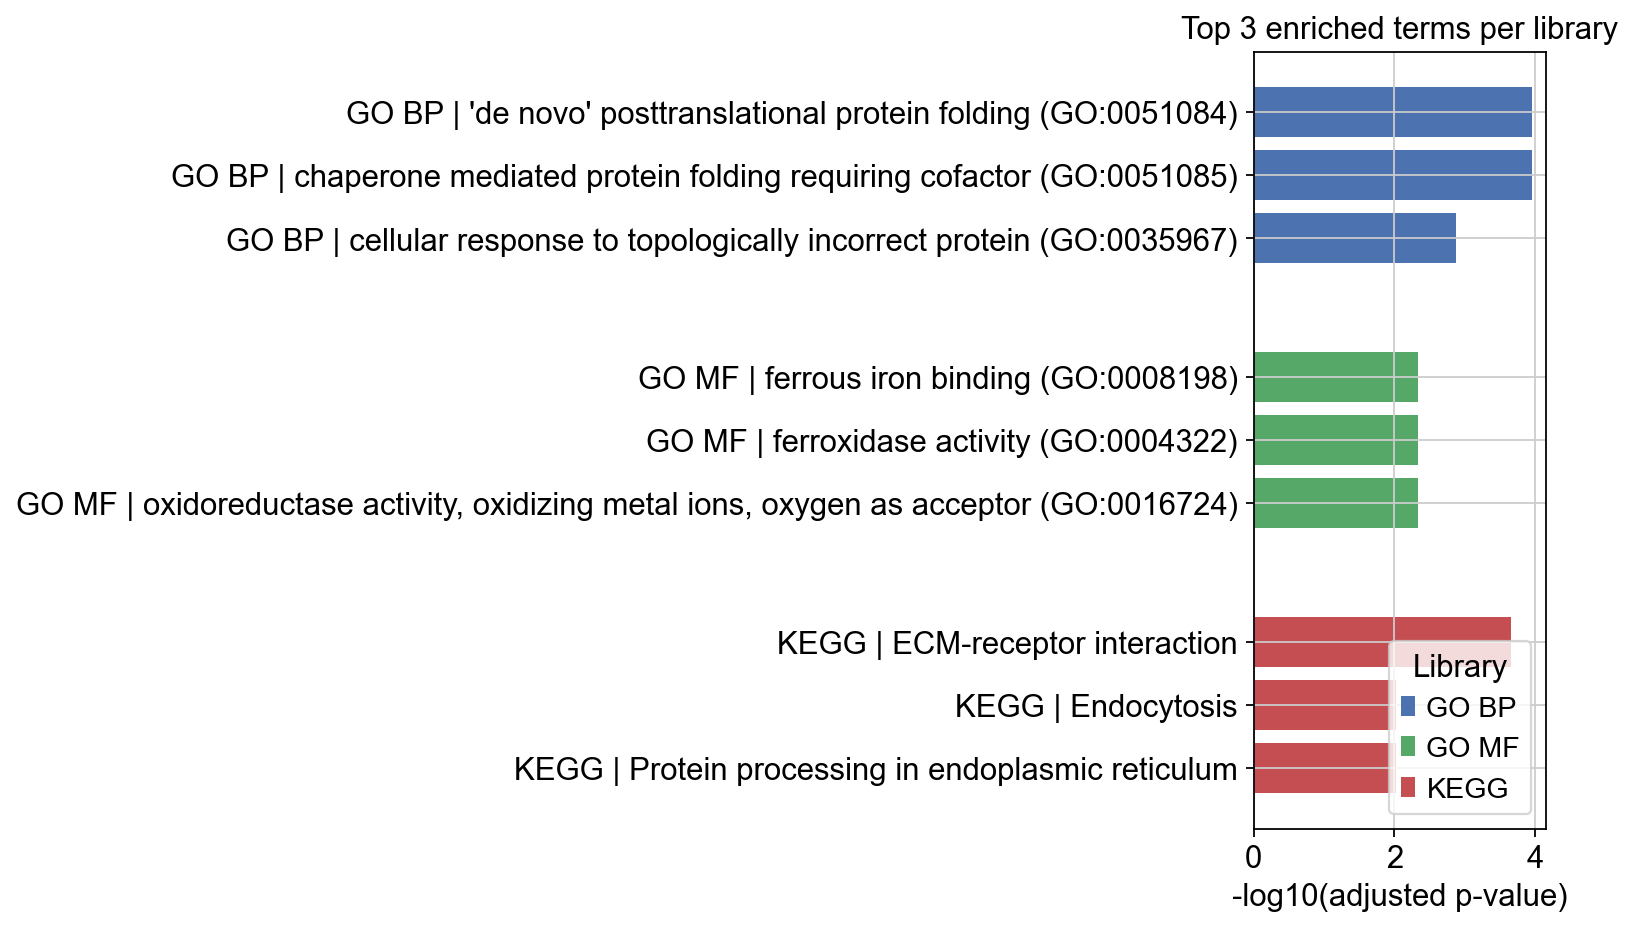

In [77]:
# run separately
tables = []
for label, lib in libs.items():
    t = run_enrichr_topn(Lan_down.index.to_list(), lib, n=3)
    t["Category"] = label
    tables.append(t)

top = pd.concat(tables, ignore_index=True)

top["neglog10_adjP"] = -np.log10(top["Adjusted P-value"].astype(float))
top["Label"] = top["Category"] + " | " + top["Term"]

# enforce order
cat_order = ["GO BP", "GO MF", "KEGG"]
top["Category"] = pd.Categorical(top["Category"], categories=cat_order, ordered=True)
top = top.sort_values(["Category", "Adjusted P-value", "Combined Score"],
                       ascending=[True, True, False])

# ---------- layout with gaps ----------
y_positions = []
labels = []
colors = []

color_map = {
    "GO BP": "#4C72B0",   # blue
    "GO MF": "#55A868",   # green
    "KEGG":  "#C44E52",   # red
}

y = 0
gap = 1.2  # vertical space between groups

for cat in cat_order:
    sub = top[top["Category"] == cat]
    for _, row in sub.iterrows():
        y_positions.append(y)
        labels.append(row["Label"])
        colors.append(color_map[cat])
        y += 1
    y += gap  # insert gap after each category

values = top["neglog10_adjP"].values

# ---------- plot ----------
plt.figure(figsize=(10, 6))
plt.barh(y_positions, values, color=colors)
plt.yticks(y_positions, labels)
plt.xlabel("-log10(adjusted p-value)")
plt.title("Top 3 enriched terms per library")
plt.gca().invert_yaxis()

# add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in cat_order]
plt.legend(handles=legend_elements, title="Library", loc="lower right")

plt.tight_layout()
plt.show()

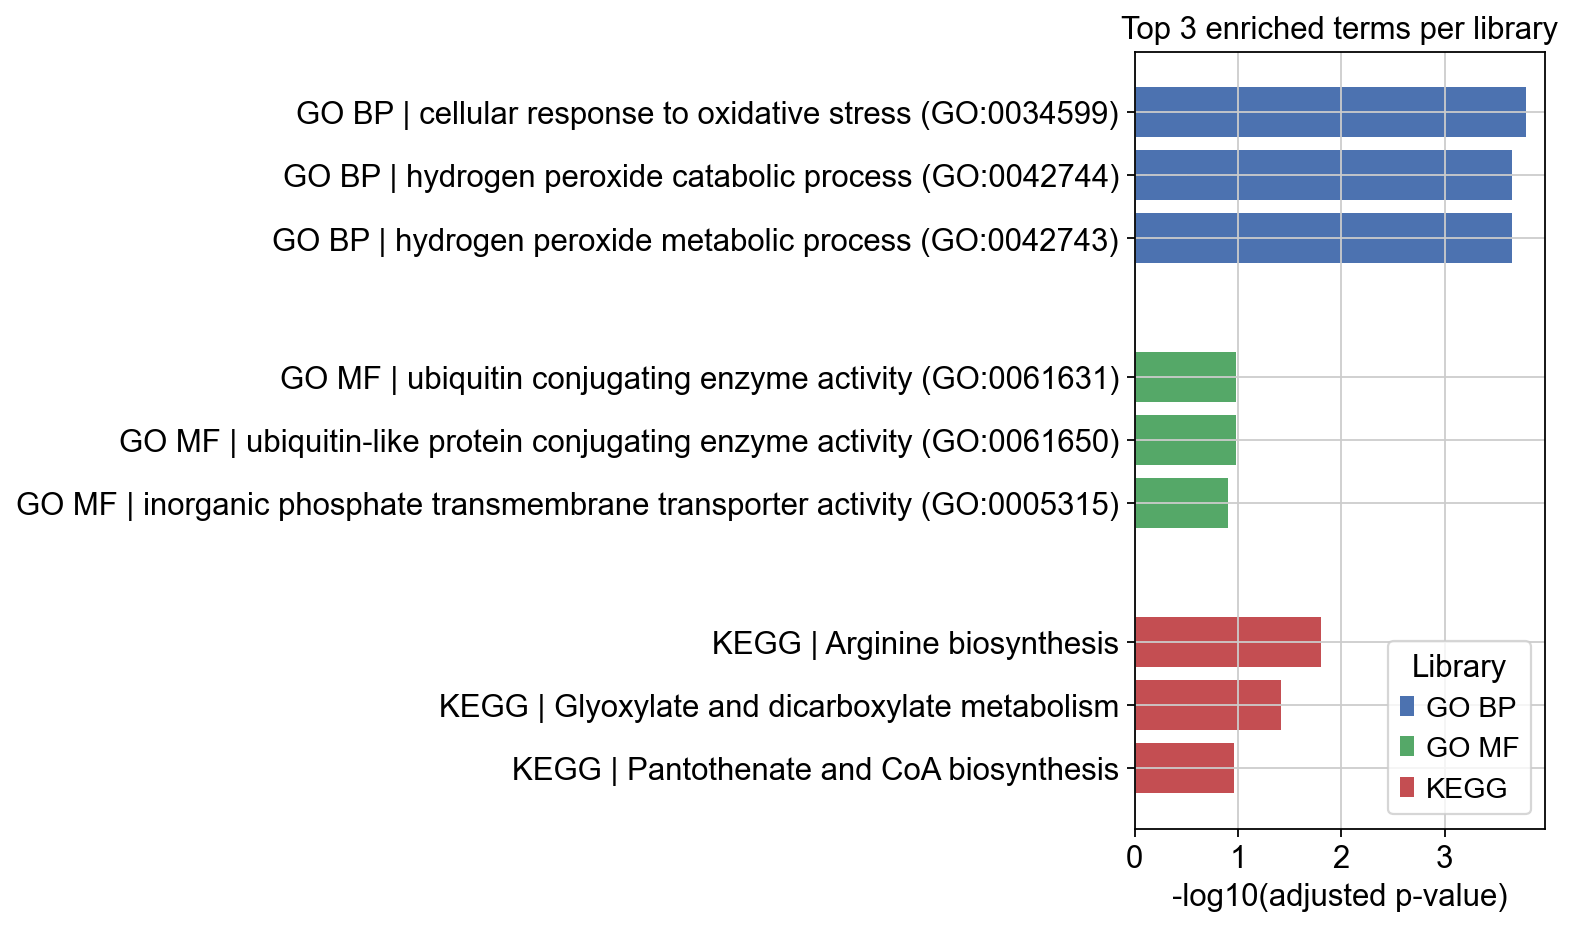

In [78]:
# run separately
tables = []
for label, lib in libs.items():
    t = run_enrichr_topn(Lan_up.index.to_list(), lib, n=3)
    t["Category"] = label
    tables.append(t)

top = pd.concat(tables, ignore_index=True)

top["neglog10_adjP"] = -np.log10(top["Adjusted P-value"].astype(float))
top["Label"] = top["Category"] + " | " + top["Term"]

# enforce order
cat_order = ["GO BP", "GO MF", "KEGG"]
top["Category"] = pd.Categorical(top["Category"], categories=cat_order, ordered=True)
top = top.sort_values(["Category", "Adjusted P-value", "Combined Score"],
                       ascending=[True, True, False])

# ---------- layout with gaps ----------
y_positions = []
labels = []
colors = []

color_map = {
    "GO BP": "#4C72B0",   # blue
    "GO MF": "#55A868",   # green
    "KEGG":  "#C44E52",   # red
}

y = 0
gap = 1.2  # vertical space between groups

for cat in cat_order:
    sub = top[top["Category"] == cat]
    for _, row in sub.iterrows():
        y_positions.append(y)
        labels.append(row["Label"])
        colors.append(color_map[cat])
        y += 1
    y += gap  # insert gap after each category

values = top["neglog10_adjP"].values

# ---------- plot ----------
plt.figure(figsize=(10, 6))
plt.barh(y_positions, values, color=colors)
plt.yticks(y_positions, labels)
plt.xlabel("-log10(adjusted p-value)")
plt.title("Top 3 enriched terms per library")
plt.gca().invert_yaxis()

# add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in cat_order]
plt.legend(handles=legend_elements, title="Library", loc="lower right")

plt.tight_layout()
plt.show()

Testing DEG with a contrast between wt and tinman:

In [ ]:
%%R -o tt
myContrast <- makeContrasts('grouptin', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

In [ ]:
%%R
str(qlf$table)  # Check available columns

In [ ]:
tt

In [ ]:
tt['logFC'] = tt['logFC'].round(2)
tt['logCPM'] = tt['logCPM'].round(2)
tt['F'] = tt['F'].round(2)
tt['PValue'] = tt['PValue'].round(2)
tt['FDR'] = tt['FDR'].round(5)
tt

In [ ]:
tin_down = tt[(tt['logFC']<0) & (tt['FDR']<0.05)]

In [ ]:
tin_down

In [85]:
display(HTML(tin_down.to_html()))

,logFC,logCPM,F,PValue,FDR
CG9184,-4.94,5.81,300.18,0.0,0.00005
Cyp6t1,-3.86,5.45,168.39,0.0,0.00050
CG10591,-4.79,3.89,121.23,0.0,0.00107
CG31313,-4.02,4.06,93.79,0.0,0.00107
CG9988,-14.18,4.29,142.87,0.0,0.00107
CG43332,-3.16,5.26,103.44,0.0,0.00219
Jheh3,-1.67,7.88,94.17,0.0,0.00219
Hsc70-3,-1.54,9.57,90.39,0.0,0.00219
Rab10,-2.65,5.80,88.59,0.0,0.00219
CG13707,-3.06,5.18,86.56,0.0,0.00219


In [ ]:
tin_up = tt[(tt['logFC']>0) & (tt['FDR']<0.05)]

In [87]:
display(HTML(tin_up.to_html()))

,logFC,logCPM,F,PValue,FDR
Cyp4g1,8.82,4.47,291.23,0.0,0.00005
Dscam4,9.10,3.28,113.15,0.0,0.00107
Cyp12a4,5.92,3.92,106.42,0.0,0.00107
phr6-4,3.53,4.78,86.98,0.0,0.00219
Hsp70Bb,2.68,7.50,77.03,0.0,0.00328
Mocs1,2.57,4.76,73.13,0.0,0.00328
Shal,3.60,3.35,62.50,0.0,0.00543
LpR1,7.88,1.41,55.24,0.0,0.00621
CG2574,10.01,2.58,65.06,0.0,0.00686
Cda5,2.99,8.63,54.68,0.0,0.00722


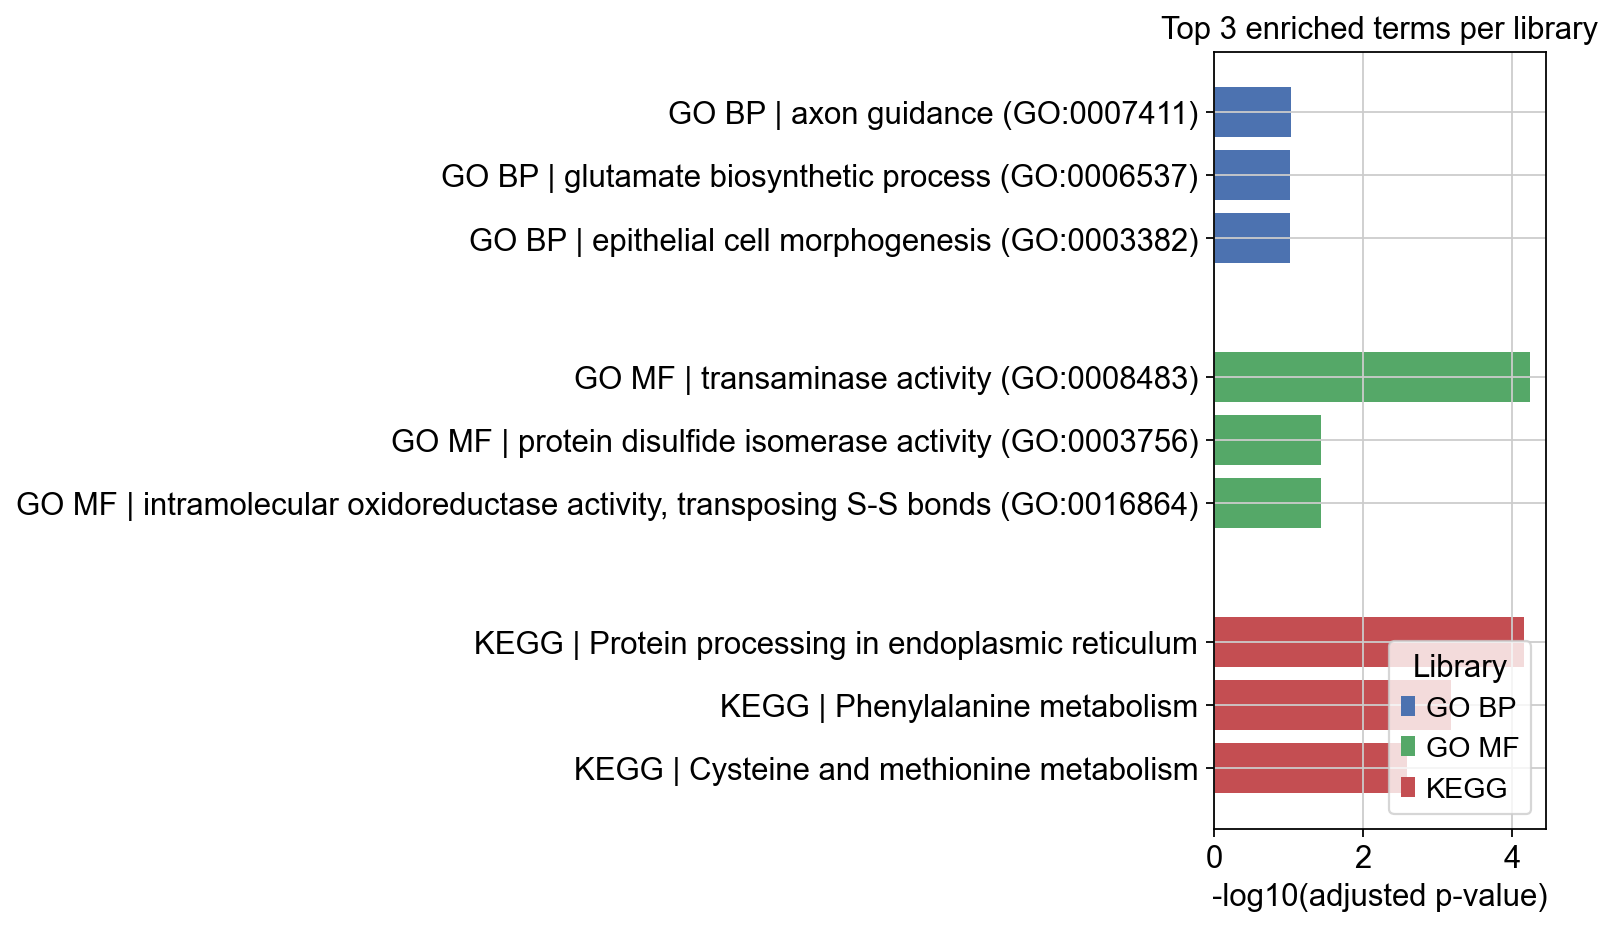

In [88]:
# run separately
tables = []
for label, lib in libs.items():
    t = run_enrichr_topn(tin_down.index.to_list(), lib, n=3)
    t["Category"] = label
    tables.append(t)

top = pd.concat(tables, ignore_index=True)

top["neglog10_adjP"] = -np.log10(top["Adjusted P-value"].astype(float))
top["Label"] = top["Category"] + " | " + top["Term"]

# enforce order
cat_order = ["GO BP", "GO MF", "KEGG"]
top["Category"] = pd.Categorical(top["Category"], categories=cat_order, ordered=True)
top = top.sort_values(["Category", "Adjusted P-value", "Combined Score"],
                       ascending=[True, True, False])

# ---------- layout with gaps ----------
y_positions = []
labels = []
colors = []

color_map = {
    "GO BP": "#4C72B0",   # blue
    "GO MF": "#55A868",   # green
    "KEGG":  "#C44E52",   # red
}

y = 0
gap = 1.2  # vertical space between groups

for cat in cat_order:
    sub = top[top["Category"] == cat]
    for _, row in sub.iterrows():
        y_positions.append(y)
        labels.append(row["Label"])
        colors.append(color_map[cat])
        y += 1
    y += gap  # insert gap after each category

values = top["neglog10_adjP"].values

# ---------- plot ----------
plt.figure(figsize=(10, 6))
plt.barh(y_positions, values, color=colors)
plt.yticks(y_positions, labels)
plt.xlabel("-log10(adjusted p-value)")
plt.title("Top 3 enriched terms per library")
plt.gca().invert_yaxis()

# add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in cat_order]
plt.legend(handles=legend_elements, title="Library", loc="lower right")

plt.tight_layout()
plt.show()

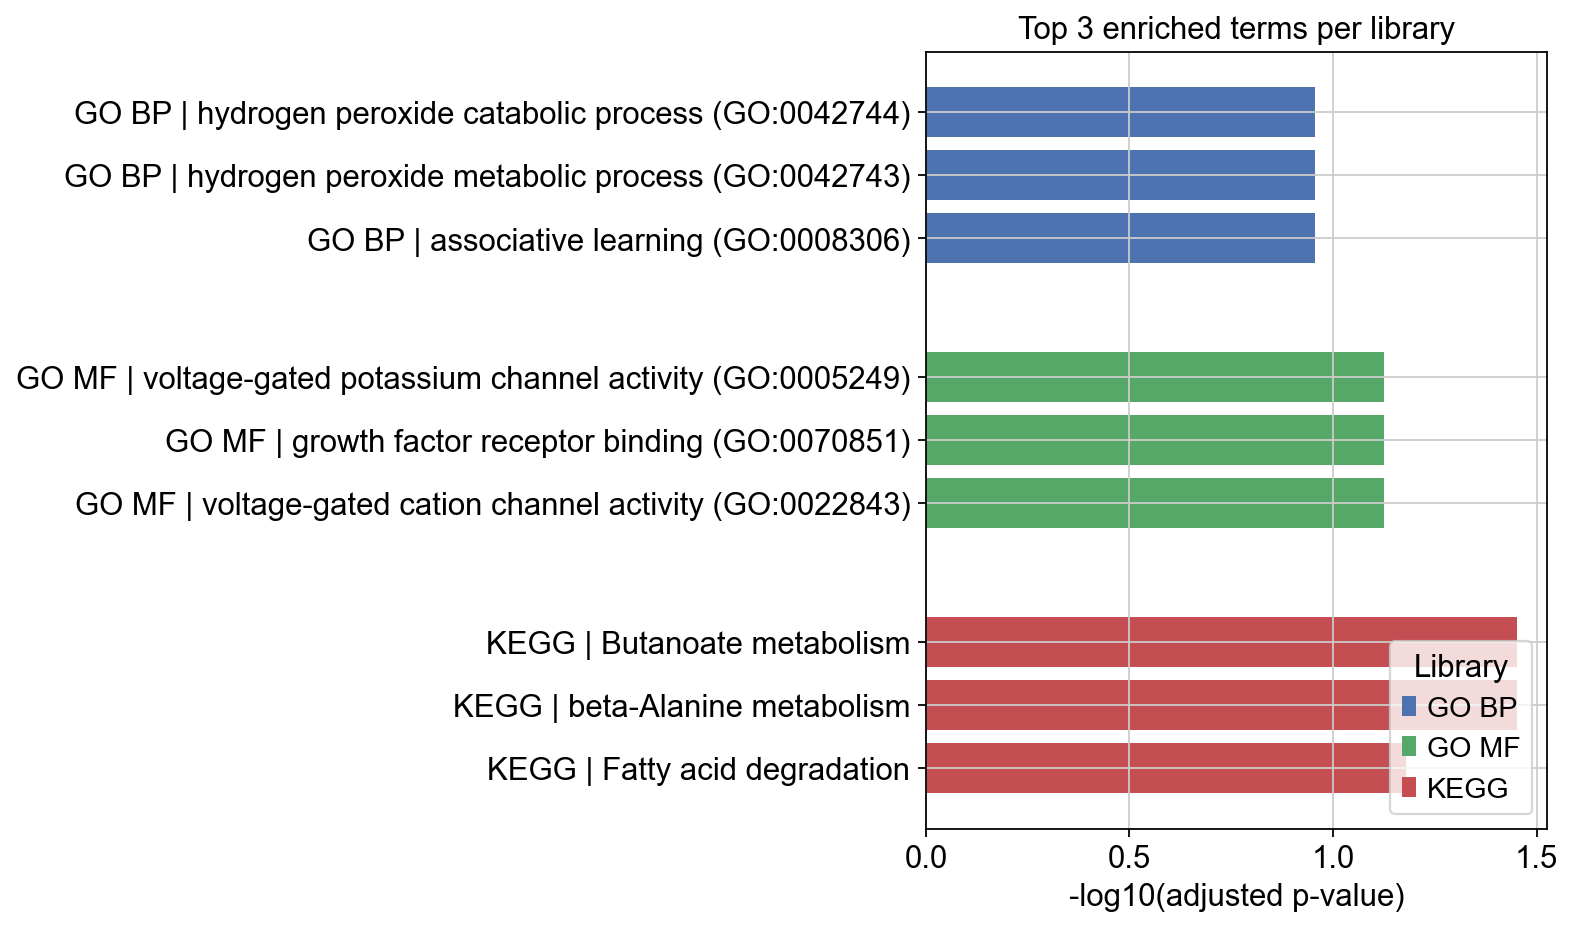

In [89]:
# run separately
tables = []
for label, lib in libs.items():
    t = run_enrichr_topn(tin_up.index.to_list(), lib, n=3)
    t["Category"] = label
    tables.append(t)

top = pd.concat(tables, ignore_index=True)

top["neglog10_adjP"] = -np.log10(top["Adjusted P-value"].astype(float))
top["Label"] = top["Category"] + " | " + top["Term"]

# enforce order
cat_order = ["GO BP", "GO MF", "KEGG"]
top["Category"] = pd.Categorical(top["Category"], categories=cat_order, ordered=True)
top = top.sort_values(["Category", "Adjusted P-value", "Combined Score"],
                       ascending=[True, True, False])

# ---------- layout with gaps ----------
y_positions = []
labels = []
colors = []

color_map = {
    "GO BP": "#4C72B0",   # blue
    "GO MF": "#55A868",   # green
    "KEGG":  "#C44E52",   # red
}

y = 0
gap = 1.2  # vertical space between groups

for cat in cat_order:
    sub = top[top["Category"] == cat]
    for _, row in sub.iterrows():
        y_positions.append(y)
        labels.append(row["Label"])
        colors.append(color_map[cat])
        y += 1
    y += gap  # insert gap after each category

values = top["neglog10_adjP"].values

# ---------- plot ----------
plt.figure(figsize=(10, 6))
plt.barh(y_positions, values, color=colors)
plt.yticks(y_positions, labels)
plt.xlabel("-log10(adjusted p-value)")
plt.title("Top 3 enriched terms per library")
plt.gca().invert_yaxis()

# add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in cat_order]
plt.legend(handles=legend_elements, title="Library", loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
Lan_down.to_csv('../data/report/DEG_lanVSwt_down_edger.csv')
Lan_up.to_csv('../data/report/DEG_lanVSwt_up_edger.csv')
tin_down.to_csv('../data/report/DEG_tinVSwt_down_edger.csv')
tin_up.to_csv('../data/report/DEG_tinVSwt_up_edger.csv')